# 04 · Entrenamiento del predictor del día siguiente

**Requiere TensorFlow** (Google Colab, o un entorno local con
`requirements.txt` instalado — ver README, sección "Entorno").

Dos pasos, con separacion temporal estricta. Primero se selecciona la
arquitectura por el ERROR EN VALIDACION (nunca en test); despues, con esa
arquitectura ya fijada, se comparan los generadores en el test final.

1. **Elegir arquitectura** (enunciado, paso 4): con SOLO la ventana real
   disponible para entrenar (sin ningún día sintético), se comparan
   baseline / lineal / densa / CNN / CNN profunda / RNN / RNN profunda —
   con nuestros bancos y 2 canales por banco (retorno + volatilidad
   realizada). La tabla generada `04_comparacion_arquitecturas.csv`
   incluye metricas de validacion (`split=validation`).
   realizada).
2. **Rejilla años de sintéticos × generador**: con la arquitectura
   (generador que relleno esos anos), evaluando siempre en el MISMO test
   real (`REAL_TEST_HOLDOUT_START_DATE` en adelante). Ese test no se usa
   para decidir la arquitectura.
   real (`REAL_TEST_HOLDOUT_START_DATE` en adelante, jamás visto por
   ningún generador ni en entrenamiento).

**Sobre las fechas** (ver `src/config.py`): la ventana real de
`REAL_INTRADAY_YEARS` (~2 años) se reparte en train/val/test — val y test
se comen la mitad, así que lo que queda para entrenar "solo con reales"
es solo ~1 año (`synth_years=0`). A partir de ahí, `synth_years` cuenta
hacia atrás desde `REAL_INTRADAY_START_DATE` cuánta historia con
volatilidad SINTÉTICA se añade — el final del entrenamiento
(`VAL_START_DATE`) es siempre el mismo, no cambia con la profundidad.

**Sobre la métrica — MAE como *loss*, no solo como número final**: la
diapositiva de teoría del taller ("REAL PROBLEM",
`2026_Taller_Generativos.pdf` pág. 11-12) especifica **"Learning:
minimize MAE"** para el problema real que motiva el taller, y reporta el
error en las unidades del target (Kelvin) — la ventaja de MAE frente a
MSE, que queda en unidades al cuadrado. El retorno diario es igual de
heavy-tailed que ese problema (ver notebook 02: la Gaussiana no
reproduce el pico leptocúrtico de los datos reales), así que entrenar
con MSE dejaría que los pocos días de retorno extremo dominen el
gradiente. Por eso aquí se entrena con `loss='mae'` (parámetro de
`build_predictor_*`, ver `LOSS_FUNCTION` más abajo). Se reportan MAE,
MSE y precisión direccional para cada modelo.

**Sobre la convergencia**: `EarlyStopping` con `patience` alto (no unas
pocas epochs) — el criterio de parada exige que `val_loss` lleve
`EARLY_STOPPING_PATIENCE` epochs SEGUIDAS sin mejorar, así que cuando un
entrenamiento para, la curva de loss ya lleva un tramo largo y plano:
es la evidencia visual de convergencia que pide el enunciado, no solo
"dejó de mejorar hace poco".

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, modelos, plotting as pl, train_utils as tu

# EPOCHS_* son un techo de seguridad, no el nº de epochs que se entrena
# realmente: tanto run_architecture_comparison como run_depth_grid paran
# antes vía EarlyStopping (ver arriba). El techo se deja holgado para que
# sea EarlyStopping, no el techo, quien decida cuándo parar.
EPOCHS_ARQUITECTURA = 300
EPOCHS_REJILLA = 500
BATCH_SIZE = 64
EARLY_STOPPING_PATIENCE = 100
LOSS_FUNCTION = "mae"

## 1. Cargar los 4 datasets de 30 años (notebook 03)

In [3]:
datasets_by_generator = {}
for name in ["noise", "gaussian", "rbig", "gan"]:
    path = config.INTERIM_DIR / f"dataset_{name}.npz"
    if not path.exists():
        continue
    npz = np.load(path, allow_pickle=True)
    idx = pd.DatetimeIndex(npz["idx"])
    datasets_by_generator[name] = (npz["X"], npz["Y"], idx, npz["is_synthetic"])
    print(f"{name}: X {npz['X'].shape}  Y {npz['Y'].shape}")

N_CHANNELS = datasets_by_generator[next(iter(datasets_by_generator))][0].shape[-1]  # 2 * N_PREDICTOR_TICKERS
assert N_CHANNELS == 2 * config.N_PREDICTOR_TICKERS

noise: X (7326, 60, 50)  Y (7326, 25)
gaussian: X (7326, 60, 50)  Y (7326, 25)
rbig: X (7326, 60, 50)  Y (7326, 25)
gan: X (7326, 60, 50)  Y (7326, 25)


## 2. Separar validación y test (reales, jamás usados por los generadores)

In [4]:
def val_test_split(X, Y, idx):
    val_mask = (idx >= pd.Timestamp(config.VAL_START_DATE)) & (idx < pd.Timestamp(config.REAL_TEST_HOLDOUT_START_DATE))
    test_mask = idx >= pd.Timestamp(config.REAL_TEST_HOLDOUT_START_DATE)
    return (X[val_mask], Y[val_mask]), (X[test_mask], Y[test_mask])

ref_name = next(iter(datasets_by_generator))
(X_val, Y_val), (X_test, Y_test) = val_test_split(*datasets_by_generator[ref_name][:3])
print(f"val: {X_val.shape}   test: {X_test.shape}")

val: (126, 60, 50)   test: (122, 60, 50)


## 3. Elegir arquitectura, usando SOLO la ventana real disponible

`synth_years=0`: ni un solo día con volatilidad sintética todavía (ver
`train_utils.slice_by_depth`) — solo el ~1 año real que queda entre
`REAL_INTRADAY_START_DATE` y `VAL_START_DATE`.

In [5]:
X_full, Y_full, idx_full, is_synth_full = datasets_by_generator[ref_name]
X_train_arch, Y_train_arch, _, _ = tu.slice_by_depth(
    X_full, Y_full, idx_full, synth_years=0,
    train_end=config.VAL_START_DATE, synth_anchor=config.REAL_INTRADAY_START_DATE,
    is_synthetic=is_synth_full,
)
print("train (arquitectura, solo reales):", X_train_arch.shape)

output_dim = config.N_PREDICTOR_TICKERS
window_x = config.WINDOW_X_DAYS

architectures = {
    "baseline": lambda: modelos.build_predictor_baseline(output_dim=output_dim),
    "linear": lambda: modelos.build_predictor_linear(),
    "dense": lambda: modelos.build_predictor_dense(
        window_x, N_CHANNELS, output_dim, hidden_units=(128, 64), loss=LOSS_FUNCTION
    ),
    "cnn_1bloque": lambda: modelos.build_predictor_cnn(
        window_x, N_CHANNELS, output_dim, conv_filters=(64,), loss=LOSS_FUNCTION
    ),
    "cnn_3bloques": lambda: modelos.build_predictor_cnn(
        window_x, N_CHANNELS, output_dim, conv_filters=(64, 128, 128), loss=LOSS_FUNCTION
    ),
    "rnn_1capa": lambda: modelos.build_predictor_rnn(
        window_x, N_CHANNELS, output_dim, lstm_units=(64,), loss=LOSS_FUNCTION
    ),
    "rnn_2capas": lambda: modelos.build_predictor_rnn(
        window_x, N_CHANNELS, output_dim, lstm_units=(64, 128), loss=LOSS_FUNCTION
    ),
}

arch_results, arch_histories = tu.run_architecture_comparison(
    architectures, X_train_arch, Y_train_arch, X_val, Y_val,
    epochs=EPOCHS_ARQUITECTURA, batch_size=BATCH_SIZE, verbose=0,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
)
arch_results.to_csv(config.TABLES_DIR / "04_comparacion_arquitecturas.csv")
arch_results.sort_values("mae")

train (arquitectura, solo reales): (252, 60, 50)


c:\Users\ORDENADOR\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


c:\Users\ORDENADOR\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000288B1EAA0C0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


c:\Users\ORDENADOR\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step


,split,fit_seconds,mse,mae,directional_accuracy
model,,,,,
rnn_2capas,validation,60.392809,0.000250,0.011489,0.532381
rnn_1capa,validation,28.566966,0.000251,0.011499,0.516190
cnn_3bloques,validation,18.452737,0.000252,0.011537,0.533968
cnn_1bloque,validation,15.710951,0.000252,0.011551,0.514286
dense,validation,16.088145,0.000258,0.011710,0.507619
linear,validation,0.168041,0.000442,0.016283,0.494286
baseline,validation,0.000871,0.000514,0.017142,0.463492


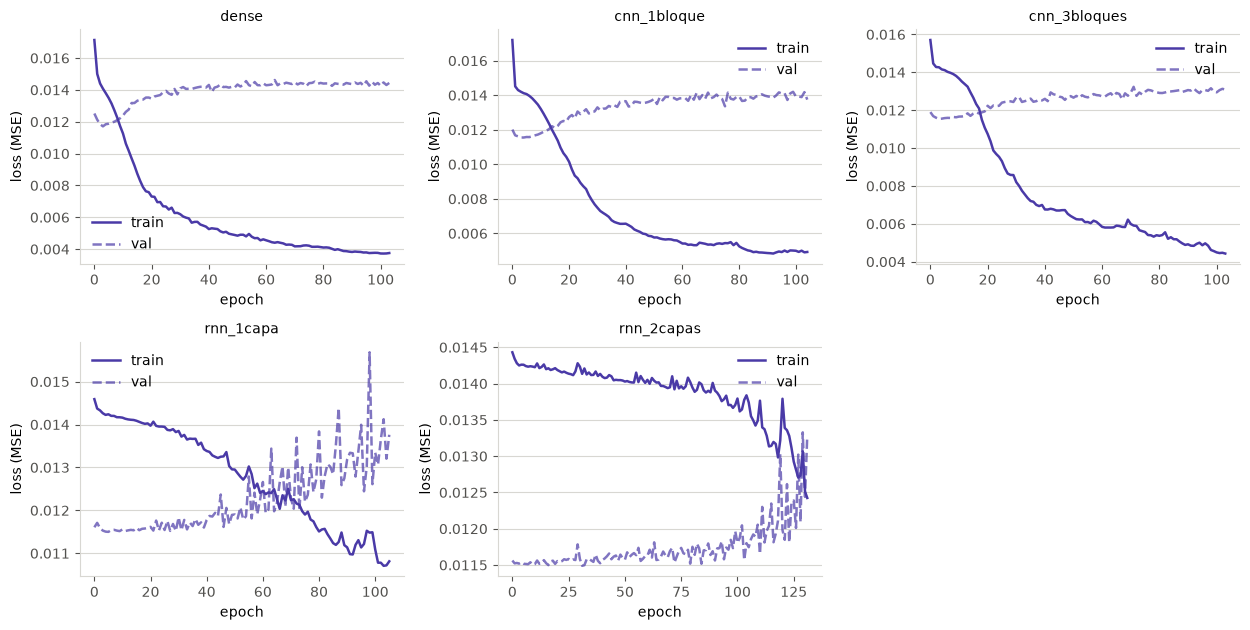

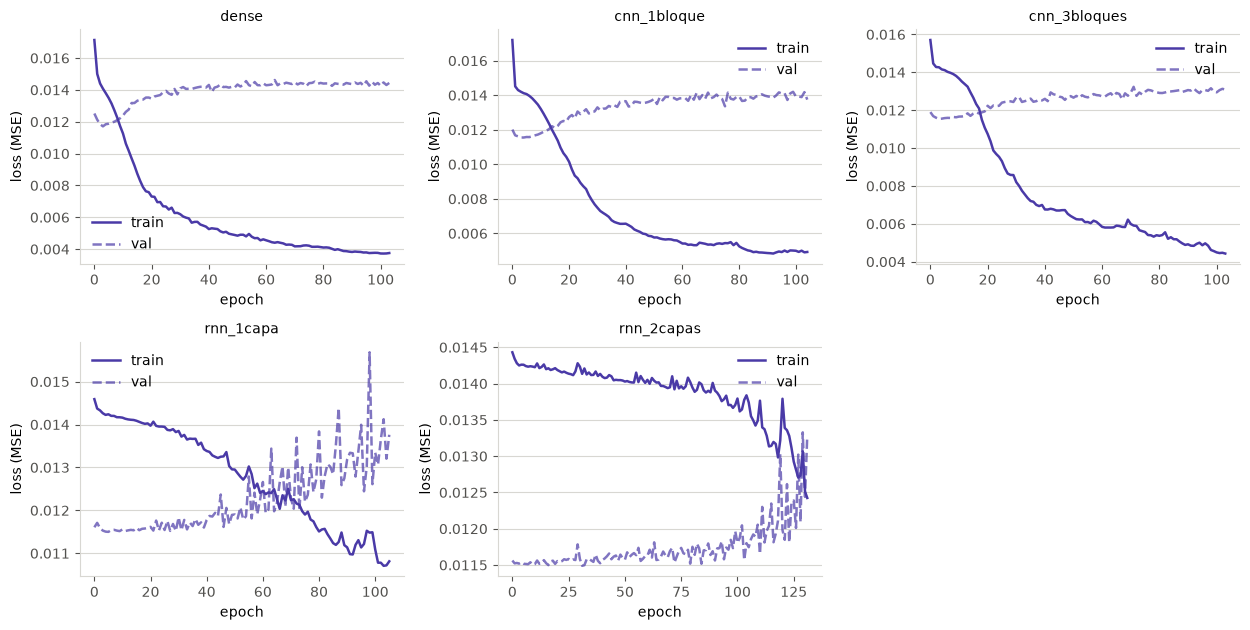

In [6]:
fig = pl.plot_loss_grid(arch_histories, ncols=3)
pl.savefig(fig, "04_loss_curvas_arquitecturas")
fig

Se elige la arquitectura con menor MAE en **validacion**. Las columnas
`mae`, `mse` y `directional_accuracy` de `arch_results` son de validacion
(`split=validation`); el test se reserva para la comparacion de generadores
del siguiente paso.

In [7]:
ARQUITECTURA_GANADORA = arch_results["mae"].idxmin()
mejor_direccional = arch_results["directional_accuracy"].idxmax()
print("Arquitectura elegida (menor MAE):", ARQUITECTURA_GANADORA)
if mejor_direccional != ARQUITECTURA_GANADORA:
    print(
        f"[AVISO] '{mejor_direccional}' tiene mejor precisión direccional "
        f"({arch_results.loc[mejor_direccional, 'directional_accuracy']:.3f} vs "
        f"{arch_results.loc[ARQUITECTURA_GANADORA, 'directional_accuracy']:.3f}) aunque peor MAE — "
        "vale la pena citar ambas arquitecturas en la presentación."
    )


def build_final_model():
    if ARQUITECTURA_GANADORA == "cnn_1bloque":
        return modelos.build_predictor_cnn(window_x, N_CHANNELS, output_dim, conv_filters=(64,), loss=LOSS_FUNCTION)
    if ARQUITECTURA_GANADORA == "cnn_3bloques":
        return modelos.build_predictor_cnn(
            window_x, N_CHANNELS, output_dim, conv_filters=(64, 128, 128), loss=LOSS_FUNCTION
        )
    if ARQUITECTURA_GANADORA == "rnn_1capa":
        return modelos.build_predictor_rnn(window_x, N_CHANNELS, output_dim, lstm_units=(64,), loss=LOSS_FUNCTION)
    if ARQUITECTURA_GANADORA == "rnn_2capas":
        return modelos.build_predictor_rnn(
            window_x, N_CHANNELS, output_dim, lstm_units=(64, 128), loss=LOSS_FUNCTION
        )
    if ARQUITECTURA_GANADORA == "dense":
        return modelos.build_predictor_dense(
            window_x, N_CHANNELS, output_dim, hidden_units=(128, 64), loss=LOSS_FUNCTION
        )
    raise ValueError(f"Arquitectura no keras seleccionada ({ARQUITECTURA_GANADORA}); revisar manualmente.")

Arquitectura elegida (menor MAE): rnn_2capas
[AVISO] 'cnn_3bloques' tiene mejor precisión direccional (0.534 vs 0.532) aunque peor MAE — vale la pena citar ambas arquitecturas en la presentación.


## 4. Rejilla años de backfill sintético × generador

`synth_years=0` es idéntico para los 4 (sin sintéticos: fila
`solo_reales`, una sola vez); a partir de ahí cada generador aporta su
propio backfill y diverge. Se calcula también el desglose MAE/MSE/
precisión direccional POR BANCO (`ticker_names`), igual que la
comparación final de `Taller_con_Datos_SP500_promedio.ipynb`: una MAE
pooleada sobre los 25 bancos queda dominada por los de mayor volatilidad
(ver notebook 01, GBCI ~1.6x más volátil que JPM).

La función guarda checkpoints en `datos/interim` tras cada combinación. Si
el notebook se interrumpe, al reejecutarlo salta las combinaciones ya
terminadas y continua desde la primera pendiente.

In [8]:
results, histories, per_ticker = tu.run_depth_grid(
    build_final_model, datasets_by_generator, X_val, Y_val, X_test, Y_test,
    synth_years_grid=config.SYNTH_DEPTH_YEARS_GRID,
    train_end=config.VAL_START_DATE,
    synth_anchor=config.REAL_INTRADAY_START_DATE,
    epochs=EPOCHS_REJILLA,
    batch_size=BATCH_SIZE,
    verbose=0,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    ticker_names=config.PREDICTOR_TICKERS,
    checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_profundidad.csv",
    history_checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_profundidad_histories.json",
    per_ticker_checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_profundidad_por_banco.csv",
)

results.to_csv(config.TABLES_DIR / "04_resultados_rejilla_profundidad.csv")
results.sort_values(["generator", "synth_years"])

[depth] saltando solo_reales, synth_years=0: ya existe checkpoint
[depth] saltando noise, synth_years=7: ya existe checkpoint
[depth] saltando gaussian, synth_years=7: ya existe checkpoint
[depth] saltando rbig, synth_years=7: ya existe checkpoint
[depth] saltando gan, synth_years=7: ya existe checkpoint
[depth] saltando noise, synth_years=14: ya existe checkpoint
[depth] saltando gaussian, synth_years=14: ya existe checkpoint
[depth] saltando rbig, synth_years=14: ya existe checkpoint
[depth] saltando gan, synth_years=14: ya existe checkpoint
[depth] saltando noise, synth_years=21: ya existe checkpoint
[depth] saltando gaussian, synth_years=21: ya existe checkpoint
[depth] saltando rbig, synth_years=21: ya existe checkpoint
[depth] saltando gan, synth_years=21: ya existe checkpoint
[depth] saltando noise, synth_years=28: ya existe checkpoint
[depth] saltando gaussian, synth_years=28: ya existe checkpoint
[depth] saltando rbig, synth_years=28: ya existe checkpoint
[depth] saltando gan,

,generator,synth_years,n_train,pct_synth,mse,mae,directional_accuracy
1,gan,7,2013,0.874814,0.000265,0.011994,0.522951
5,gan,14,3774,0.933227,0.000256,0.011844,0.542623
9,gan,21,5537,0.954488,0.000250,0.011756,0.527541
13,gan,28,7078,0.964397,0.000251,0.011779,0.520328
2,gaussian,7,2013,0.874814,0.000251,0.011760,0.535738
6,gaussian,14,3774,0.933227,0.000267,0.012291,0.499344
10,gaussian,21,5537,0.954488,0.000270,0.012243,0.514754
14,gaussian,28,7078,0.964397,0.000256,0.011888,0.523279
3,noise,7,2013,0.874814,0.000260,0.011914,0.546230
7,noise,14,3774,0.933227,0.000263,0.012114,0.515082


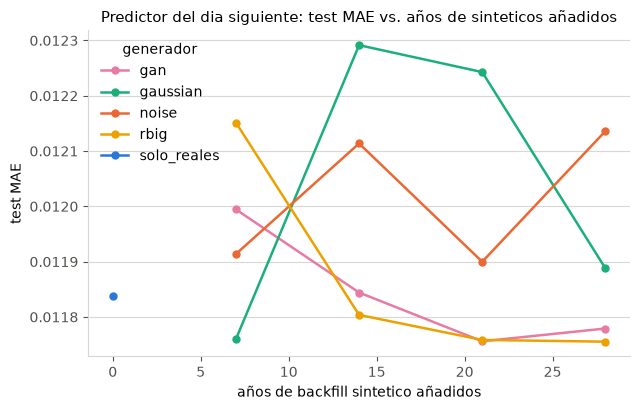

In [15]:
fig = pl.plot_depth_grid_results(results, metric="mae")
pl.savefig(fig, "04_mae_vs_profundidad")
plt.show()

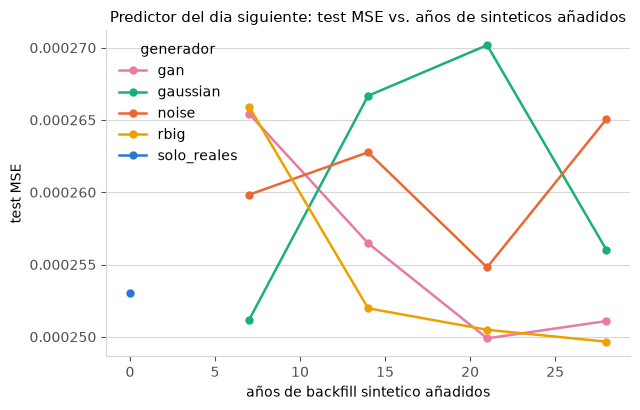

In [16]:
fig = pl.plot_depth_grid_results(results, metric="mse")
pl.savefig(fig, "04_mse_vs_profundidad")
plt.show()

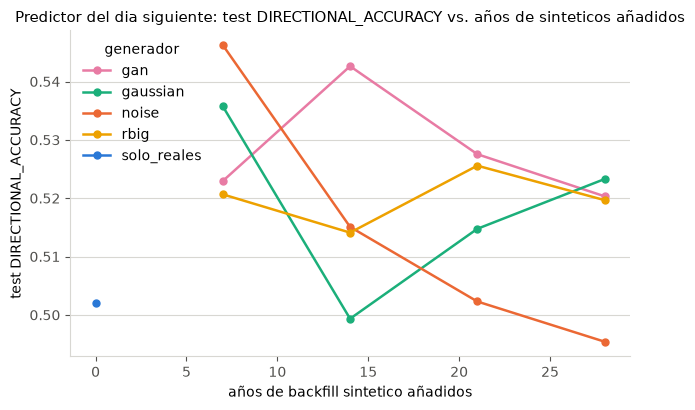

In [17]:
fig = pl.plot_depth_grid_results(results, metric="directional_accuracy")
pl.savefig(fig, "04_precision_direccional_vs_profundidad")
plt.show()

## 5. Desglose por banco a máxima profundidad sintética

Gráfico de barras agrupado MAE por banco y generador (misma idea que el
bloque final de `Taller_con_Datos_SP500_promedio.ipynb`), en el punto de
mayor profundidad de la rejilla.

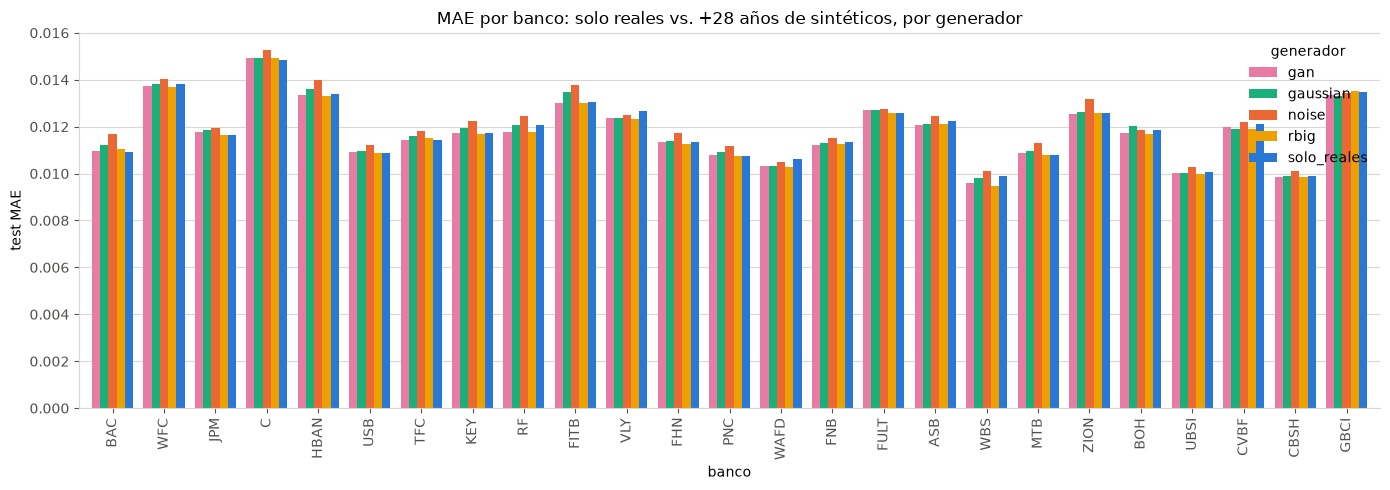

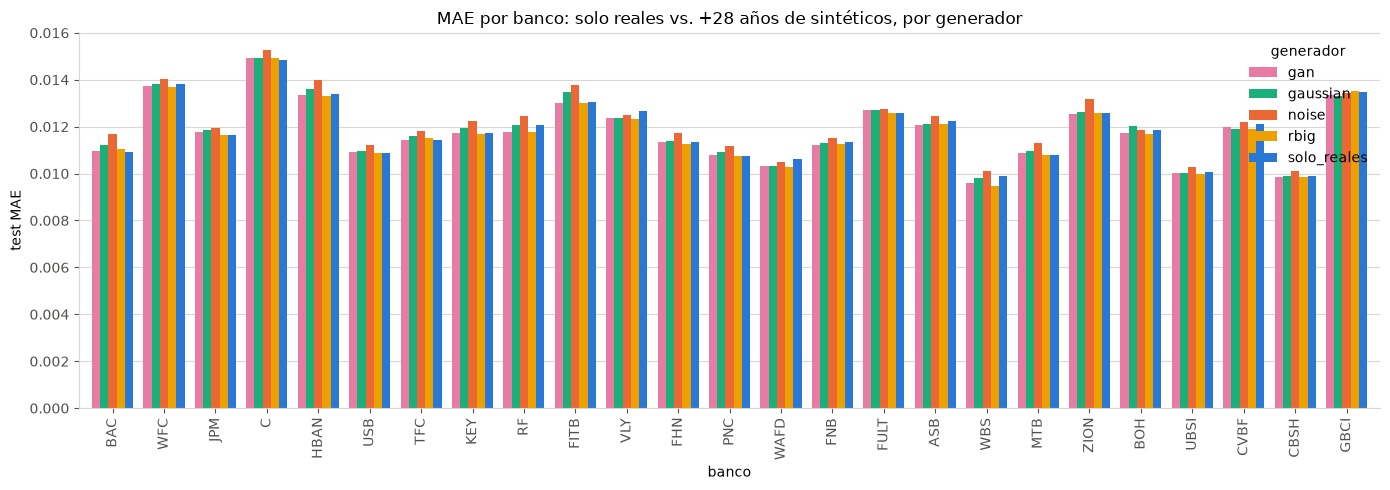

In [12]:
synth_years_max = config.SYNTH_DEPTH_YEARS_GRID[-1]
per_ticker_final = {
    gen_name: df for (gen_name, sy), df in per_ticker.items() if sy == synth_years_max
}
per_ticker_final["solo_reales"] = per_ticker[("solo_reales", config.SYNTH_DEPTH_YEARS_GRID[0])]

per_ticker_table = pd.concat(
    {name: df["mae"] for name, df in per_ticker_final.items()}, axis=1
)
per_ticker_table.to_csv(config.TABLES_DIR / "04_mae_por_banco.csv")

fig, ax = plt.subplots(figsize=(14, 5))
per_ticker_table.plot(
    kind="bar", ax=ax,
    color=[pl.color_for(c) for c in per_ticker_table.columns],
    width=0.8,
)
ax.set_ylabel("test MAE")
ax.set_xlabel("banco")
ax.set_title(f"MAE por banco: solo reales vs. +{synth_years_max} años de sintéticos, por generador")
ax.legend(frameon=False, title="generador")
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "04_mae_por_banco")
fig

## 6. Curvas de loss: `solo_reales` (synth_years=0) vs. historia completa
   (synth_years=28), por generador

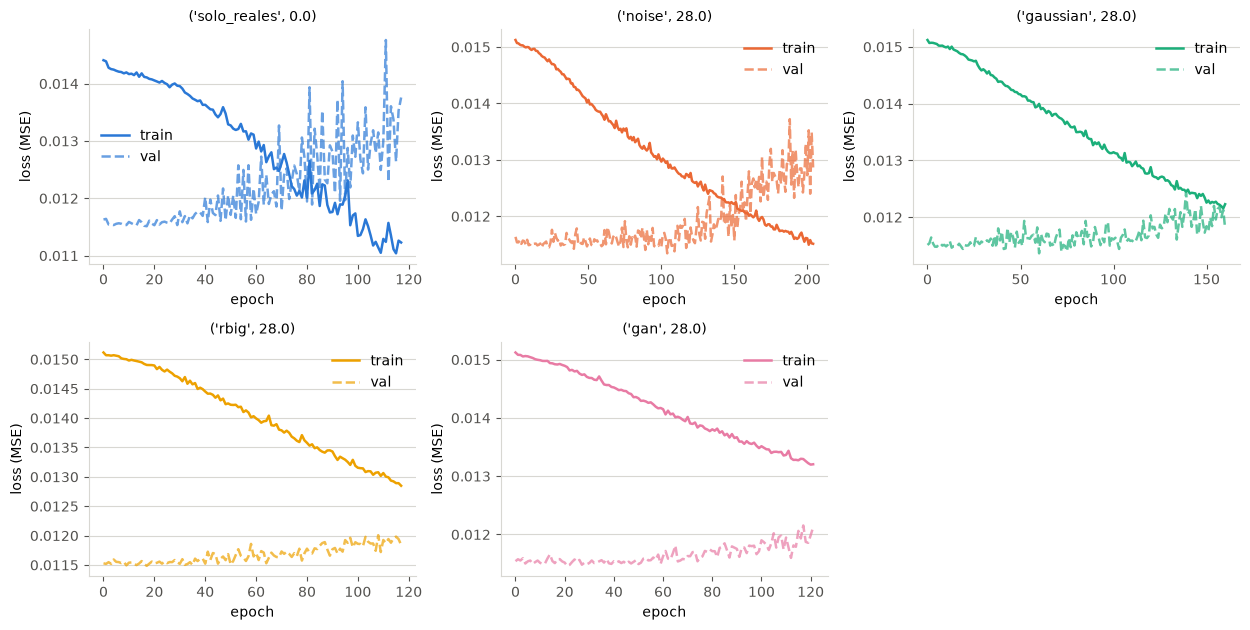

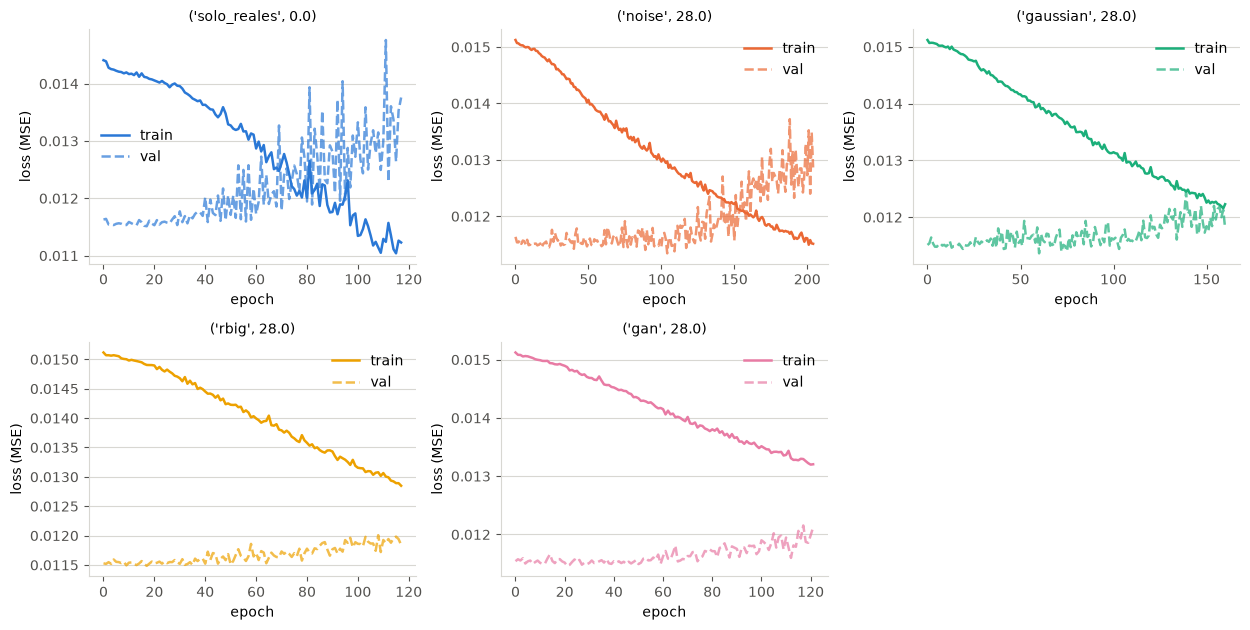

In [13]:
subset_histories = {
    k: v for k, v in histories.items()
    if k[1] in (config.SYNTH_DEPTH_YEARS_GRID[0], config.SYNTH_DEPTH_YEARS_GRID[-1])
}
fig = pl.plot_loss_grid(subset_histories, ncols=3)
pl.savefig(fig, "04_loss_curvas_rejilla")
fig

## 7. Guardar resultados consolidados (`datos/interim/`, gitignored)

El notebook 05 solo lee estos CSV/tablas — no vuelve a entrenar nada.

In [14]:
results.to_pickle(config.INTERIM_DIR / "resultados_finales.pkl")
per_ticker_table.to_pickle(config.INTERIM_DIR / "resultados_por_banco.pkl")
print("Listo. Tabla completa en reports/tables/04_resultados_rejilla_profundidad.csv")

Listo. Tabla completa en reports/tables/04_resultados_rejilla_profundidad.csv
